# Final evaluation

Model: CitrusNet, checkpoint `checkpoints/baseline_best.pt`. This is the configuration selected after the ablation study (Adam, full architecture, dropout + L2 + BatchNorm, full augmentation) - see the ablation notebooks for how it was picked.

In [1]:
import json
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

from citrus_model import CitrusNet
from citrus_common import get_transforms, CitrusLeafDataset

Device and normalization stats.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sync():
    # no-op on CPU, needed so the latency timing below is accurate on GPU
    if device.type == "cuda":
        torch.cuda.synchronize()

device

device(type='cuda')

In [3]:
with open("normalization_stats.json") as f:
    norm_stats = json.load(f)

mean = tuple(norm_stats["mean"])
std = tuple(norm_stats["std"])

class_to_idx = {"aphids": 0, "gummosis": 1, "healthy": 2, "leaf_minnor": 3}
class_names = sorted(class_to_idx, key=class_to_idx.get)
class_names

['aphids', 'gummosis', 'healthy', 'leaf_minnor']

Load the model and the final checkpoint.

In [4]:
model = CitrusNet(num_classes=4)
state_dict = torch.load("checkpoints/baseline_best.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()
model.to(device)

CitrusNet(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (1): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), pad

Build the test set. Same transform as validation - no augmentation, just resize and normalize.

In [5]:
test_transform = get_transforms(augment=False, mean=mean, std=std, size=224)
test_dataset = CitrusLeafDataset(root_dir="processed/224", split="test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

len(test_dataset)

240

First and only use of the test set in this project. It has not been touched, viewed, or used for any decision until this point.

In [6]:
all_true = []
all_pred = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_true.append(labels.numpy())
        all_pred.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

true_labels = np.concatenate(all_true)
pred_labels = np.concatenate(all_pred)
probs = np.concatenate(all_probs)

true_labels.shape, pred_labels.shape, probs.shape

((240,), (240,), (240, 4))

Overall accuracy and per-class precision/recall/F1.

In [7]:
accuracy = accuracy_score(true_labels, pred_labels)
print(f"Test accuracy: {accuracy:.4f}")

report = classification_report(true_labels, pred_labels, target_names=class_names, digits=4)
print(report)

Test accuracy: 0.9667
              precision    recall  f1-score   support

      aphids     1.0000    1.0000    1.0000        60
    gummosis     0.9831    0.8923    0.9355        65
     healthy     0.9107    1.0000    0.9533        51
 leaf_minnor     0.9692    0.9844    0.9767        64

    accuracy                         0.9667       240
   macro avg     0.9657    0.9692    0.9664       240
weighted avg     0.9682    0.9667    0.9664       240



In [8]:
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="macro")
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted")

print(f"Macro    - P: {macro_p:.4f}  R: {macro_r:.4f}  F1: {macro_f1:.4f}")
print(f"Weighted - P: {weighted_p:.4f}  R: {weighted_r:.4f}  F1: {weighted_f1:.4f}")

Macro    - P: 0.9657  R: 0.9692  F1: 0.9664
Weighted - P: 0.9682  R: 0.9667  F1: 0.9664


Confusion matrix.

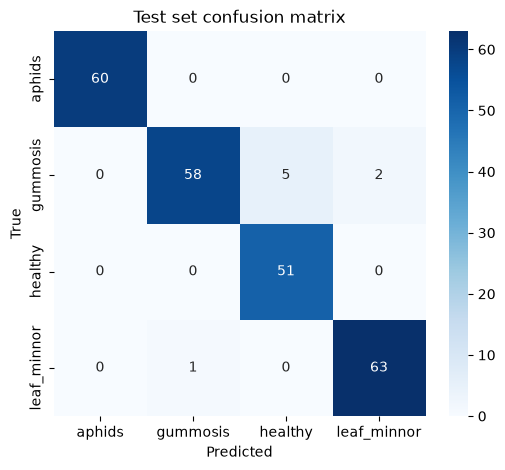

In [9]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test set confusion matrix")
plt.show()

In [10]:
n_errors = int(cm.sum() - np.trace(cm))

if n_errors == 0:
    print("No misclassifications on the test set.")
else:
    print(f"{n_errors} misclassified image(s):")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                print(f"  {class_names[i]} -> {class_names[j]}: {cm[i, j]}")

8 misclassified image(s):
  gummosis -> healthy: 5
  gummosis -> leaf_minnor: 2
  leaf_minnor -> gummosis: 1


ROC-AUC, one-vs-rest, per class.

In [11]:
y_true_bin = label_binarize(true_labels, classes=list(range(len(class_names))))

# average=None returns one AUC per class, in the same class order as true_labels
per_class_auc_arr = roc_auc_score(true_labels, probs, multi_class="ovr", average=None)
per_class_auc = {cls: float(auc) for cls, auc in zip(class_names, per_class_auc_arr)}
per_class_auc

{'aphids': 1.0,
 'gummosis': 0.9992967032967033,
 'healthy': 1.0,
 'leaf_minnor': 0.9892578125}

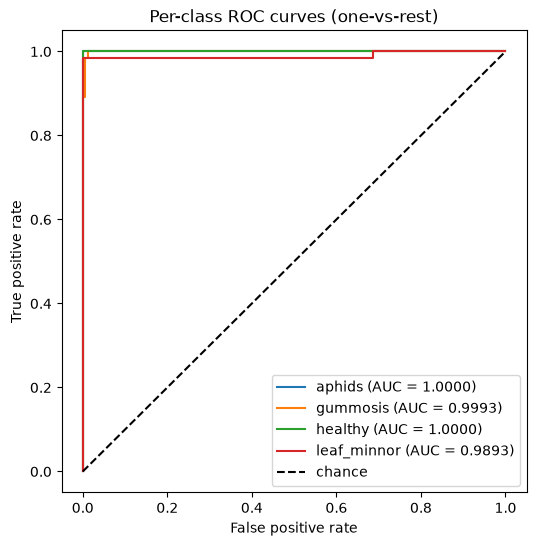

In [12]:
plt.figure(figsize=(6, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {per_class_auc[cls]:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Per-class ROC curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.show()

Model efficiency: size and inference speed.

In [13]:
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / (1024 ** 2)  # float32, 4 bytes per parameter

print(f"Parameters: {total_params:,} (expected 416,036)")
print(f"Model size: {model_size_mb:.3f} MB")

Parameters: 416,036 (expected 416,036)
Model size: 1.587 MB


In [14]:
model.eval()

# one untimed pass first so CUDA context/cache setup doesn't skew the timed runs
with torch.no_grad():
    warm_img, _ = test_dataset[0]
    _ = model(warm_img.unsqueeze(0).to(device))
    sync()

latencies_ms = []
with torch.no_grad():
    for i in range(100):
        img, _ = test_dataset[i % len(test_dataset)]
        img = img.unsqueeze(0).to(device)

        sync()
        start = time.perf_counter()
        _ = model(img)
        sync()
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000)

latencies_ms = np.array(latencies_ms)
mean_latency_ms = float(latencies_ms.mean())
std_latency_ms = float(latencies_ms.std())
throughput = 1000 / mean_latency_ms

print(f"Mean latency: {mean_latency_ms:.3f} ms (std {std_latency_ms:.3f} ms)")
print(f"Throughput: {throughput:.1f} images/sec")

Mean latency: 2.028 ms (std 0.130 ms)
Throughput: 493.1 images/sec


Grad-CAM, same setup as the interpretability-check notebook: hooks on `block4`, weighted activation map, upsampled and overlaid on the image. One image per class - the misclassified one if there is one, otherwise a correctly classified one.

In [15]:
gradcam_activations = {}
gradcam_gradients = {}

def _forward_hook(module, inp, out):
    gradcam_activations["value"] = out.detach()

def _backward_hook(module, grad_in, grad_out):
    gradcam_gradients["value"] = grad_out[0].detach()

fh = model.block4.register_forward_hook(_forward_hook)
bh = model.block4.register_full_backward_hook(_backward_hook)

def grad_cam(img_tensor, target_class):
    model.zero_grad()
    img_tensor = img_tensor.unsqueeze(0).to(device)

    logits = model(img_tensor)
    probs_single = F.softmax(logits, dim=1)[0]
    logits[0, target_class].backward()

    activ = gradcam_activations["value"][0]   # (C, H, W)
    grads = gradcam_gradients["value"][0]      # (C, H, W)

    weights = grads.mean(dim=(1, 2))
    cam = torch.relu((weights[:, None, None] * activ).sum(dim=0))
    cam = cam.cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, probs_single.detach().cpu().numpy()

In [16]:
selected_indices = []
for cls_idx in range(len(class_names)):
    class_mask = true_labels == cls_idx
    wrong = np.where(class_mask & (pred_labels != true_labels))[0]
    right = np.where(class_mask & (pred_labels == true_labels))[0]
    selected_indices.append(int(wrong[0]) if len(wrong) > 0 else int(right[0]))

selected_indices

[0, 113, 125, 215]

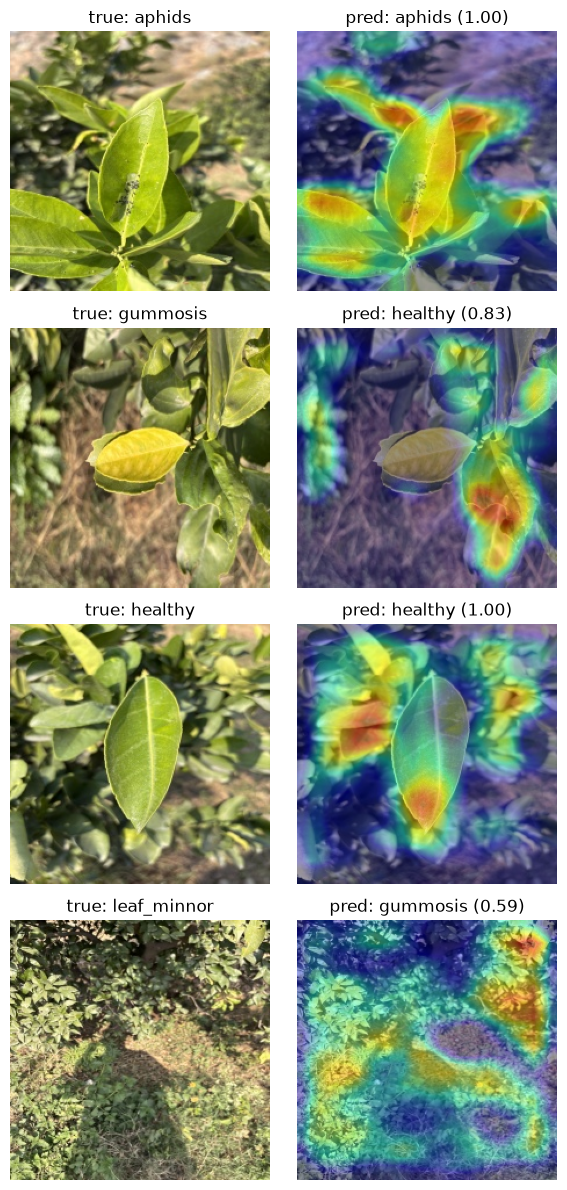

In [17]:
mean_arr = np.array(mean).reshape(3, 1, 1)
std_arr = np.array(std).reshape(3, 1, 1)

def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy() * std_arr + mean_arr
    img = np.clip(img, 0, 1)
    return (img.transpose(1, 2, 0) * 255).astype(np.uint8)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for row, idx in enumerate(selected_indices):
    img_tensor, true_idx = test_dataset[idx]
    pred_idx = int(pred_labels[idx])
    cam, probs_single = grad_cam(img_tensor, target_class=pred_idx)

    orig = unnormalize(img_tensor)
    cam_resized = cv2.resize(cam, (orig.shape[1], orig.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(heatmap * 0.4 + orig * 0.6)

    conf = probs_single[pred_idx]

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"true: {class_names[true_idx]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f"pred: {class_names[pred_idx]} ({conf:.2f})")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

fh.remove()
bh.remove()

Save the final numbers.

In [18]:
results = {
    "test_accuracy": float(accuracy),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p),
    "weighted_recall": float(weighted_r),
    "weighted_f1": float(weighted_f1),
    "per_class_auc": per_class_auc,
    "num_parameters": int(total_params),
    "model_size_mb": float(model_size_mb),
    "mean_inference_latency_ms": mean_latency_ms,
    "std_inference_latency_ms": std_latency_ms,
    "throughput_images_per_sec": float(throughput),
}

with open("final_test_results.json", "w") as f:
    json.dump(results, f, indent=2)

results

{'test_accuracy': 0.9666666666666667,
 'macro_precision': 0.9657489756006705,
 'macro_recall': 0.9691706730769231,
 'macro_f1': 0.9663747712629092,
 'weighted_precision': 0.9682312620289316,
 'weighted_recall': 0.9666666666666667,
 'weighted_f1': 0.9663954247907771,
 'per_class_auc': {'aphids': 1.0,
  'gummosis': 0.9992967032967033,
  'healthy': 1.0,
  'leaf_minnor': 0.9892578125},
 'num_parameters': 416036,
 'model_size_mb': 1.5870513916015625,
 'mean_inference_latency_ms': 2.02788200462237,
 'std_inference_latency_ms': 0.12955712759665003,
 'throughput_images_per_sec': 493.12533851604394}

Report card.

In [19]:
mean_auc = float(np.mean(list(per_class_auc.values())))

print("=" * 40)
print("FINAL REPORT CARD")
print("=" * 40)
print(f"Test accuracy:           {accuracy:.4f}")
print(f"Macro F1:                {macro_f1:.4f}")
print(f"Mean AUC:                {mean_auc:.4f}")
print(f"Parameters:              {total_params:,}")
print(f"Model size:              {model_size_mb:.3f} MB")
print(f"Mean inference latency:  {mean_latency_ms:.3f} ms")
print("=" * 40)

FINAL REPORT CARD
Test accuracy:           0.9667
Macro F1:                0.9664
Mean AUC:                0.9971
Parameters:              416,036
Model size:              1.587 MB
Mean inference latency:  2.028 ms
